In [ ]:
#%pip install pandas==2.2.3
#%pip install git+https://github.com/pydata/pandas-datareader.git
#%pip install yfinance numpy matplotlib
#%pip install shap
#%pip install lime

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd #Importamos pandas para el manejo de dataframes y series temporales
import numpy as np #Importamos numpy para operaciones numéricas y manejo de arrays
from sklearn.ensemble import GradientBoostingRegressor #Importamos el modelo de regresión Gradient Boosting de scikit-learn para realizar predicciones
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit #Importamos GridSearchCV para la búsqueda de hiperparámetros y TimeSeriesSplit para la validación cruzada específica para series temporales
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer #Importamos métricas de evaluación para medir el rendimiento del modelo, como el error absoluto medio (MAE) y el error cuadrático medio (MSE)
import joblib #Importamos joblib para guardar y cargar modelos de manera eficiente
import matplotlib.pyplot as plt #Importamos matplotlib para la visualización de datos y resultados
from sklearn.linear_model import LinearRegression #Importamos LinearRegression para comparar el rendimiento del modelo de Gradient Boosting con un modelo lineal
from sklearn.isotonic import IsotonicRegression #Importamos IsotonicRegression para realizar regresión isotónica, que es una técnica de ajuste de curvas monotónicas
import shap
import lime
import lime.lime_tabular

c:\Users\34620\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('../../dataset_ml.csv')
df.head()

#df.drop(columns=['Date'], inplace=True) #Eliminamos la columna 'Date' ya que no es una característica numérica y no aporta información relevante para el modelo. Además, eliminamos la columna 'target' ya que es la variable que queremos predecir.

,oro_return,precio,inflacion_usa,volatilidad_6m,lag_3,tipos_ecb,eurusd,activo_return,desempleo,sp500_return,...,inflacion_usa_lag1,inflacion_usa_lag3,inflacion_usa_lag6,vix_lag1,vix_lag2,vix_lag3,desempleo_lag1,desempleo_lag3,curva10Y2Y_lag1,curva10Y2Y_lag3
0,0.047631,0.320155,0.020352,0.088742,-0.083592,1.0,1.259002,0.021998,5.7,0.050766,...,0.020348,0.020352,0.020352,18.234399,18.309999,18.309999,5.7,5.7,2.42505,2.43000
1,-0.032475,0.337983,0.020263,0.081350,0.104730,1.0,1.245206,0.055686,5.7,0.017276,...,0.020352,0.020352,0.020352,18.309999,18.234399,18.309999,5.7,5.7,2.43000,2.43000
2,0.022960,0.358358,0.016885,0.079723,-0.086500,1.0,1.253007,0.060284,5.6,0.012209,...,0.020263,0.020348,0.020352,16.629999,18.309999,18.234399,5.7,5.7,2.32000,2.42505
3,0.038561,0.405100,0.017401,0.076144,0.021998,1.0,1.231300,0.130434,5.8,-0.016359,...,0.016885,0.020352,0.020352,14.550000,16.629999,18.309999,5.6,5.7,2.33000,2.43000
4,-0.094313,0.386223,0.022926,0.078530,0.055686,1.0,1.198294,-0.046598,5.6,-0.016791,...,0.017401,0.020263,0.020352,16.740000,14.550000,16.629999,5.8,5.7,2.26000,2.32000


In [4]:
X = df.drop(columns=['target']) #Separamos las características (X) de la variable objetivo (Y) para preparar los datos para el entrenamiento del modelo de machine learning.
Y = df['target']

In [5]:
def division_conjuntos(dataframe, tr_size=0.8, vl_size=0.1, ts_size=0.1 ):
    '''Función para dividir un dataframe en conjuntos de entrenamiento, validación y prueba.
    Parámetros:
    dataframe: DataFrame a dividir
    tr_size: Proporción de datos para el conjunto de entrenamiento (default=0.8)
    vl_size: Proporción de datos para el conjunto de validación (default=0.1)
    ts_size: Proporción de datos para el conjunto de prueba (default=0.1)
    Retorna:
    train: DataFrame de entrenamiento
    val: DataFrame de validación
    test: DataFrame de prueba
    '''
    N = dataframe.shape[0] # Número total de datos
    Ntrain = int(tr_size*N)  # Número de datos de entrenamiento
    Nval = int(vl_size*N)    # Número de datos de validación
    Ntst = int(ts_size*N)    # Número de datos de prueba

    # Realizar partición
    train = dataframe[0:Ntrain] # Conjunto de entrenamiento
    val = dataframe[Ntrain:Ntrain+Nval] # Conjunto de validación
    test = dataframe[Ntrain+Nval:] # Conjunto de prueba

    return train, val, test

# Prueba de la función
tr, vl, ts = division_conjuntos(df) # Dividimos el dataframe en conjuntos de entrenamiento, validación y prueba utilizando la función division_conjuntos.

X_train = tr.drop(columns=['target']) # Separamos las características (X) de la variable objetivo (Y) para el conjunto de entrenamiento, eliminando la columna 'target' que es la variable que queremos predecir.
y_train = tr['target']

X_val = vl.drop(columns=['target']) # Separamos las características (X) de la variable objetivo (Y) para el conjunto de validación, eliminando la columna 'target' que es la variable que queremos predecir.
y_val = vl['target']

X_test = ts.drop(columns=['target']) # Separamos las características (X) de la variable objetivo (Y) para el conjunto de prueba, eliminando la columna 'target' que es la variable que queremos predecir.
y_test = ts['target']

print(f'Entrenamiento: {X_train.shape}')
print(f'Validación: {X_val.shape}')
print(f'Prueba: {X_test.shape}')

Entrenamiento: (212, 26)
Validación: (26, 26)
Prueba: (27, 26)


In [6]:
def directional_accuracy(y_true, y_pred):
    true_dir = np.sign(y_true)
    pred_dir = np.sign(y_pred)
    valid = true_dir != 0
    if valid.sum() == 0:
        return 0
    return np.mean(true_dir[valid] == pred_dir[valid])

# Creamos el scorer para GridSearch
da_scorer = make_scorer(directional_accuracy, greater_is_better=True)

In [7]:
param_grid_gb = {
    'n_estimators': [300, 400, 500],
    'learning_rate': [0.03, 0.05, 0.08],    # Tasa de aprendizaje para controlar la contribución de cada árbol
    'max_depth': [4, 5, 6],                 # Profundidad máxima de los árboles
    'subsample': [0.7, 0.8, 0.9],           # Nivel de aleatorización para cada árbol
    'min_samples_split': [10, 20, 50],      # Numero mínimo de muestras para dividir un nodo
    'min_samples_leaf': [5, 10, 15],        # Numero mínimo de muestras por hoja
    'loss': ['huber']                        #← CAMBIA: usa 'huber' para mayor robustez a outliers
} #Definimos una cuadrícula de hiperparámetros para el modelo de Gradient Boosting Regressor

# Validación cruzada temporal (misma que para Random Forest)
ts_cv = TimeSeriesSplit(n_splits=3) #Definimos una estrategia de validación cruzada para series temporales utilizando TimeSeriesSplit, que divide los datos en conjuntos de entrenamiento y validación respetando el orden temporal de los datos.

# Inicializar el modelo
gb = GradientBoostingRegressor(random_state=42) #Creamos una instancia del modelo de regresión Gradient Boosting Regressor con una semilla aleatoria fija para garantizar la reproducibilidad de los resultados.

# Búsqueda en rejilla
grid_search_gb = GridSearchCV( 
    estimator=gb,
    param_grid=param_grid_gb,
    cv=ts_cv,
    scoring=da_scorer,
    verbose=1,
    n_jobs=-1
) # Configuramos la búsqueda de hiperparámetros utilizando GridSearchCV, especificando el modelo, la cuadrícula de hiperparámetros, la estrategia de validación cruzada, la métrica de evaluación (en este caso, la precisión direccional), y habilitando la salida detallada y el uso de múltiples núcleos para acelerar el proceso.

# Ajustar la búsqueda
grid_search_gb.fit(X_train, y_train) #Ejecutamos la búsqueda de hiperparámetros ajustando el modelo a los datos de entrenamiento utilizando la configuración definida en GridSearchCV.

# Mejores hiperparámetros
print(f"Mejores hiperparámetros: {grid_search_gb.best_params_}")
print(f"Mejor MAE: {-grid_search_gb.best_score_:.4f}")

Fitting 3 folds for each of 729 candidates, totalling 2187 fits
Mejores hiperparámetros: {'learning_rate': 0.08, 'loss': 'huber', 'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 20, 'n_estimators': 500, 'subsample': 0.7}
Mejor MAE: -0.6226


In [ ]:
best_gb = GradientBoostingRegressor(**grid_search_gb.best_params_, random_state=42) #Creamos una nueva instancia del modelo de Gradient Boosting Regressor utilizando los mejores hiperparámetros encontrados en la búsqueda y una semilla aleatoria fija para garantizar la reproducibilidad.
# Entrenamiento con early stopping manual
best_gb.fit(X_train, y_train)

# Verificar si necesita más árboles
if hasattr(best_gb, 'train_score_'):
    print(f"Puntuación final de entrenamiento: {best_gb.train_score_[-1]:.6f}")
    
y_pred_val_raw = best_gb.predict(X_val) #Realizamos predicciones utilizando el modelo entrenado con los mejores hiperparámetros en el conjunto de validación para evaluar su rendimiento.
y_pred_test = best_gb.predict(X_test)

# Entrenar calibrador en validación
calibrator_iso = IsotonicRegression(out_of_bounds='clip')
calibrator_iso.fit(y_pred_val_raw, y_val)

# Aplicar calibración a test
y_pred_test_calibrated = calibrator_iso.predict(y_pred_test)

# Ver el efecto de la calibración
print("\n=== EFECTO DE LA CALIBRACIÓN (ISOTÓNICA) ===")
print(f"Media real (test): {y_test.mean():.4f}")
print(f"Media predicción original: {y_pred_test.mean():.4f}")
print(f"Media predicción calibrada: {y_pred_test_calibrated.mean():.4f}")

# Calcular R² original y calibrado
r2_original = r2_score(y_test, y_pred_test)
r2_calibrado = r2_score(y_test, y_pred_test_calibrated)

print(f"\nR² original: {r2_original:.4f}")
print(f"R² calibrado: {r2_calibrado:.4f}")

# Decidir cuál usar
if r2_calibrado > r2_original:
    print("\nUsando predicciones CALIBRADAS (mejor R²)")
    y_pred_test = y_pred_test_calibrated
else:
    print("\nUsando predicciones ORIGINALES")

y_pred_val = calibrator_iso.predict(y_pred_val_raw) if r2_calibrado > r2_original else y_pred_val_raw

mae_val = mean_absolute_error(y_val, y_pred_val) #Calculamos el error absoluto medio (MAE) entre las predicciones del modelo y los valores reales en el conjunto de validación para medir la precisión de las predicciones.
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val)) #Calculamos la raíz del error cuadrático medio (RMSE) entre las predicciones del modelo y los valores reales en el conjunto de validación para medir la precisión de las predicciones, penalizando más los errores grandes.
r2_val = r2_score(y_val, y_pred_val)
da_val = directional_accuracy(y_val, y_pred_val)

print(f"MAE: {mae_val:.4f}")
print(f"RMSE: {rmse_val:.4f}")
print(f"R²: {r2_val:.4f}") 
print(f"DA: {da_val:.4f}")

Puntuación final de entrenamiento: 0.000001

=== EFECTO DE LA CALIBRACIÓN (ISOTÓNICA) ===
Media real (test): 0.0186
Media predicción original: 0.0227
Media predicción calibrada: 0.0122

R² original: 0.1574
R² calibrado: -0.0124

⚠️ Usando predicciones ORIGINALES
MAE: 0.0843
RMSE: 0.0991
R²: -0.4511
DA: 0.4231


MAE: 0.0843
RMSE: 0.0991
R²: -0.4511
DA: 0.4231

In [9]:
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)
da_test = directional_accuracy(y_test, y_pred_test)

print(f"MAE: {mae_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"R²: {r2_test:.4f}")
print(f"DA: {da_test:.4f}")

MAE: 0.0437
RMSE: 0.0531
R²: 0.1574
DA: 0.6296


MAE: 0.0437
RMSE: 0.0531
R²: 0.1574
DA: 0.6296

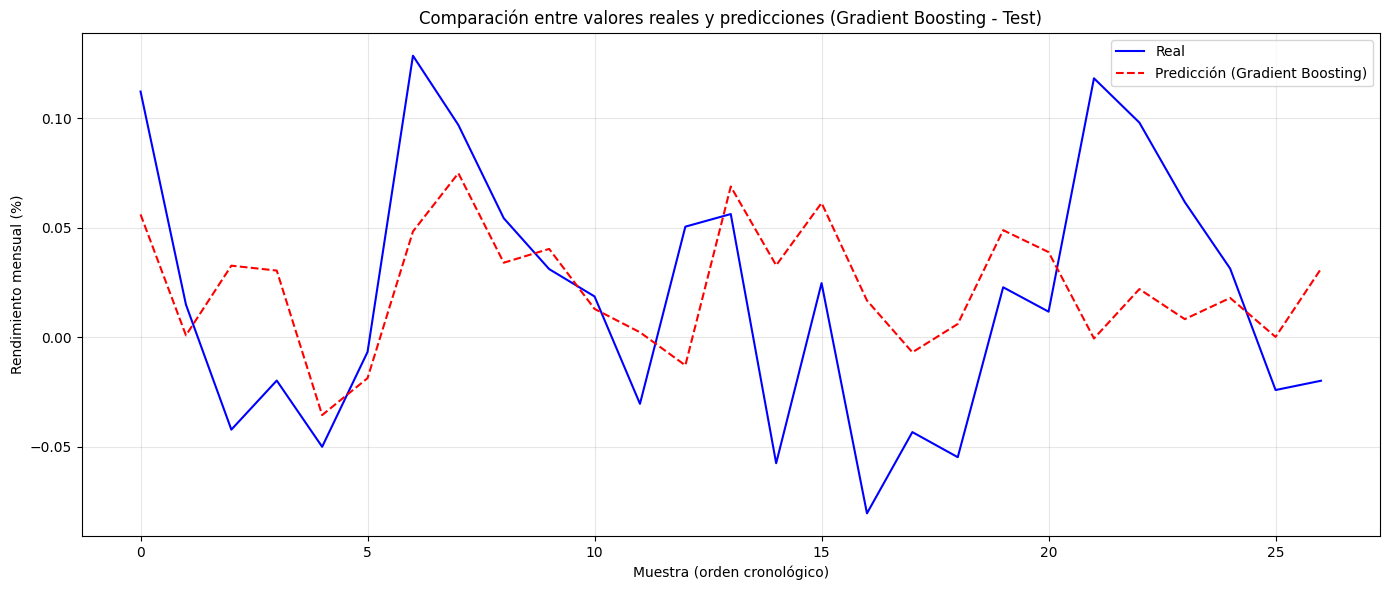

In [10]:
plt.figure(figsize=(14, 6))

# Ordenar por índice (asegurar orden cronológico)
indices = range(len(y_test))

plt.plot(indices, y_test.values, label='Real', color='blue', linewidth=1.5)
plt.plot(indices, y_pred_test, label='Predicción (Gradient Boosting)', color='red', linestyle='--', linewidth=1.5)

plt.title('Comparación entre valores reales y predicciones (Gradient Boosting - Test)')
plt.xlabel('Muestra (orden cronológico)')
plt.ylabel('Rendimiento mensual (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [11]:
def backtesting_gb(dataframe, window_train=200, test_size=24, step=12, best_params=None):
    """
    Realiza backtesting con ventana deslizante para Gradient Boosting.
    
    Parámetros:
    -----------
    dataframe : DataFrame
        Dataset completo ordenado cronológicamente
    window_train : int
        Tamaño de la ventana de entrenamiento (meses)
    test_size : int
        Tamaño de la ventana de prueba (meses)
    step : int
        Número de meses que se desplaza la ventana en cada iteración
    best_params : dict
        Mejores hiperparámetros encontrados en la búsqueda previa
        
    Retorna:
    --------
    resultados : DataFrame
        DataFrame con las métricas de cada iteración
    media_metricas : dict
        Diccionario con las métricas promedio
    """
    
    resultados = []  # Lista para almacenar los resultados de cada iteración
    
    # Si no se proporcionan mejores hiperparámetros, se usan valores por defecto
    if best_params is None:
        best_params = {
            'n_estimators': 300,
            'learning_rate': 0.05,
            'max_depth': 5,
            'subsample': 0.8,
            'min_samples_split': 20,
            'min_samples_leaf': 10,
            'loss': 'huber',
            'random_state': 42
        }
    
    # Calculamoa número total de iteraciones que se realizarán en el backtesting
    n_iterations = (len(dataframe) - window_train - test_size) // step + 1
    
    # Iteramos sobre el rango de índices para crear las ventanas de entrenamiento y prueba
    for i, start in enumerate(range(0, len(dataframe) - window_train - test_size, step)):
        
        # Definimos los límites de las ventanas
        train_end = start + window_train
        test_end = train_end + test_size
        
        # Obtenemos los datos de entrenamiento y prueba
        train = dataframe.iloc[start:train_end]
        test = dataframe.iloc[train_end:test_end]
        
        # Separamos características (X) y variable objetivo (y)
        X_train = train.drop(columns=['target'])
        y_train = train['target']
        
        X_test = test.drop(columns=['target'])
        y_test = test['target']
        
        # Creamos y entrenamos el modelo con los mejores hiperparámetros
        gb = GradientBoostingRegressor(**best_params)
        gb.fit(X_train, y_train)
        
        # Realizamos predicciones
        y_pred = gb.predict(X_test)
        
        # Calculamos métricas
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        da = directional_accuracy(y_test, y_pred)
        
        # Información de las fechas (si el índice es numérico, mostrar rangos)
        if isinstance(dataframe.index, pd.RangeIndex):
            periodo_train = f"[{start}:{train_end-1}]"
            periodo_test = f"[{train_end}:{test_end-1}]"
        else: #Si el índice es de tipo fecha, mostrar los rangos de fechas
            periodo_train = f"{train.index[0]} - {train.index[-1]}"
            periodo_test = f"{test.index[0]} - {test.index[-1]}"
        
        # Guardar los resultados de cada iteración
        resultados.append({
            'iteracion': i + 1,
            'train_inicio': start,
            'train_fin': train_end - 1,
            'test_inicio': train_end,
            'test_fin': test_end - 1,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'DA': da
        })
        
    # Convertir la lista de resultados a un DataFrame
    df_resultados = pd.DataFrame(resultados)
    
    # Calcular métricas promedio y su desviación estándar
    media_metricas = {
        'MAE_mean': df_resultados['MAE'].mean(),
        'MAE_std': df_resultados['MAE'].std(),
        'RMSE_mean': df_resultados['RMSE'].mean(),
        'RMSE_std': df_resultados['RMSE'].std(),
        'R2_mean': df_resultados['R2'].mean(),
        'R2_std': df_resultados['R2'].std(),
        'DA_mean': df_resultados['DA'].mean(),
        'DA_std': df_resultados['DA'].std()
    }
    
    print(f"MAE medio: {media_metricas['MAE_mean']:.4f} (±{media_metricas['MAE_std']:.4f})")
    print(f"RMSE medio: {media_metricas['RMSE_mean']:.4f} (±{media_metricas['RMSE_std']:.4f})")
    print(f"R² medio: {media_metricas['R2_mean']:.4f} (±{media_metricas['R2_std']:.4f})")
    print(f"DA medio: {media_metricas['DA_mean']:.4f} (±{media_metricas['DA_std']:.4f})")   
    
    return df_resultados, media_metricas


In [12]:
best_params_gb = grid_search_gb.best_params_
best_params_gb['random_state'] = 42

# Ejecutamos backtesting
resultados_backtest, metricas_backtest = backtesting_gb(
    dataframe=df,
    window_train=220,  # 200 meses de entrenamiento (~16.7 años)
    test_size=20,      # 24 meses de prueba (~2 años)
    step=12,           # Desplazar la ventana 12 meses cada iteración
    best_params=best_params_gb
)

MAE medio: 0.0602 (±0.0210)
RMSE medio: 0.0734 (±0.0248)
R² medio: -0.1684 (±0.2465)
DA medio: 0.5500 (±0.1323)


MAE medio: 0.0729 (±0.0378)
RMSE medio: 0.0865 (±0.0409)
R² medio: -0.1832 (±0.2970)
DA medio: 0.4167 (±0.2357)

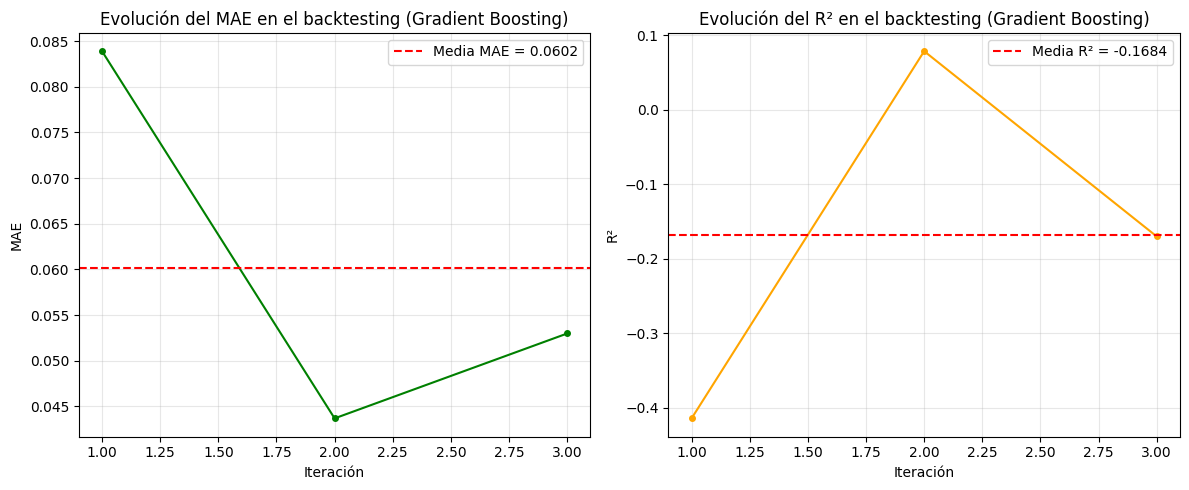

In [13]:
plt.figure(figsize=(12, 5))

# Subgráfica 1: Evolución del MAE en el backtesting
plt.subplot(1, 2, 1)
plt.plot(resultados_backtest['iteracion'], resultados_backtest['MAE'], 'o-', color='green', markersize=4)
plt.axhline(y=metricas_backtest['MAE_mean'], color='red', linestyle='--', label=f'Media MAE = {metricas_backtest["MAE_mean"]:.4f}')
plt.xlabel('Iteración')
plt.ylabel('MAE')
plt.title('Evolución del MAE en el backtesting (Gradient Boosting)')
plt.legend()
plt.grid(True, alpha=0.3)

# Subgráfica 2: Evolución del R² en el backtesting
plt.subplot(1, 2, 2)
plt.plot(resultados_backtest['iteracion'], resultados_backtest['R2'], 'o-', color='orange', markersize=4)
plt.axhline(y=metricas_backtest['R2_mean'], color='red', linestyle='--', label=f'Media R² = {metricas_backtest["R2_mean"]:.4f}')
plt.xlabel('Iteración')
plt.ylabel('R²')
plt.title('Evolución del R² en el backtesting (Gradient Boosting)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== GRADIENT BOOSTING - VALIDACIÓN ===
MAE: 0.0716
RMSE: 0.0834



In [14]:
#joblib.dump(best_gb, 'gradient_boosting_model.pkl')

In [15]:
# Tomamos una muestra representativa del entrenamiento (100 muestras)
X_train_sample = X_train.sample(n=min(100, len(X_train)), random_state=42)

# TreeExplainer funciona también para Gradient Boosting
print("Creando explainer para Gradient Boosting...")
explainer_gb = shap.TreeExplainer(best_gb)

# Calcular los valores SHAP para el conjunto de prueba
print("Calculando valores SHAP para Gradient Boosting...")
shap_values_gb = explainer_gb.shap_values(X_test)

Creando explainer para Gradient Boosting...
Calculando valores SHAP para Gradient Boosting...


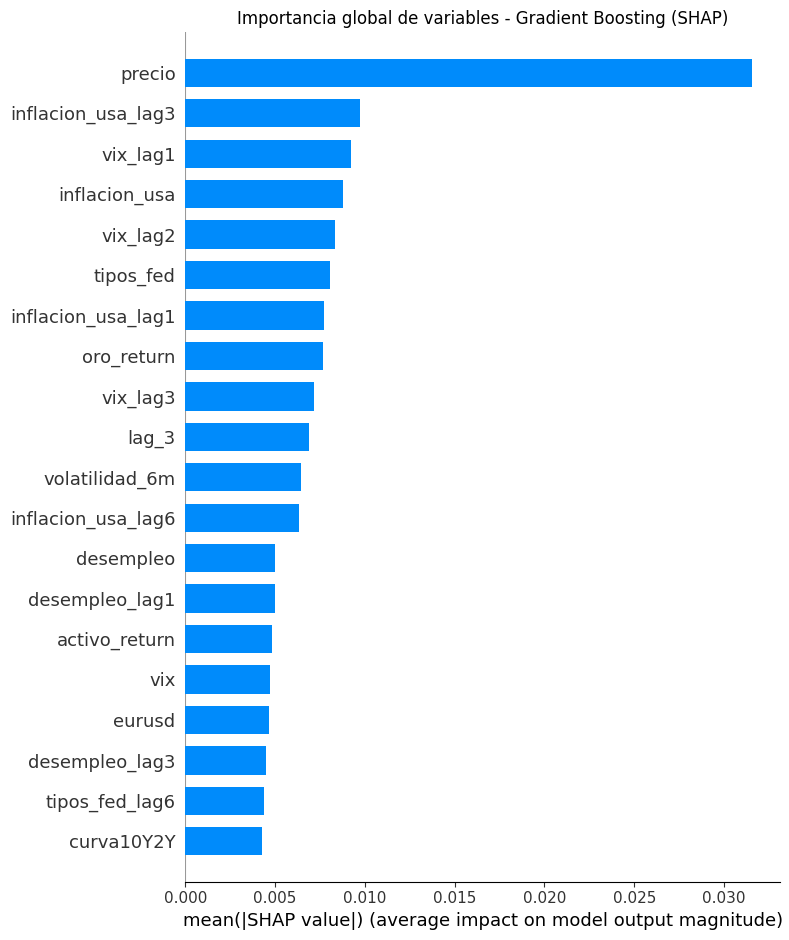

In [16]:
# 2. GRÁFICA 1: Importancia global de variables (mean absolute SHAP)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_gb, X_test, plot_type="bar", show=False)
plt.title("Importancia global de variables - Gradient Boosting (SHAP)")
plt.tight_layout()
plt.show()

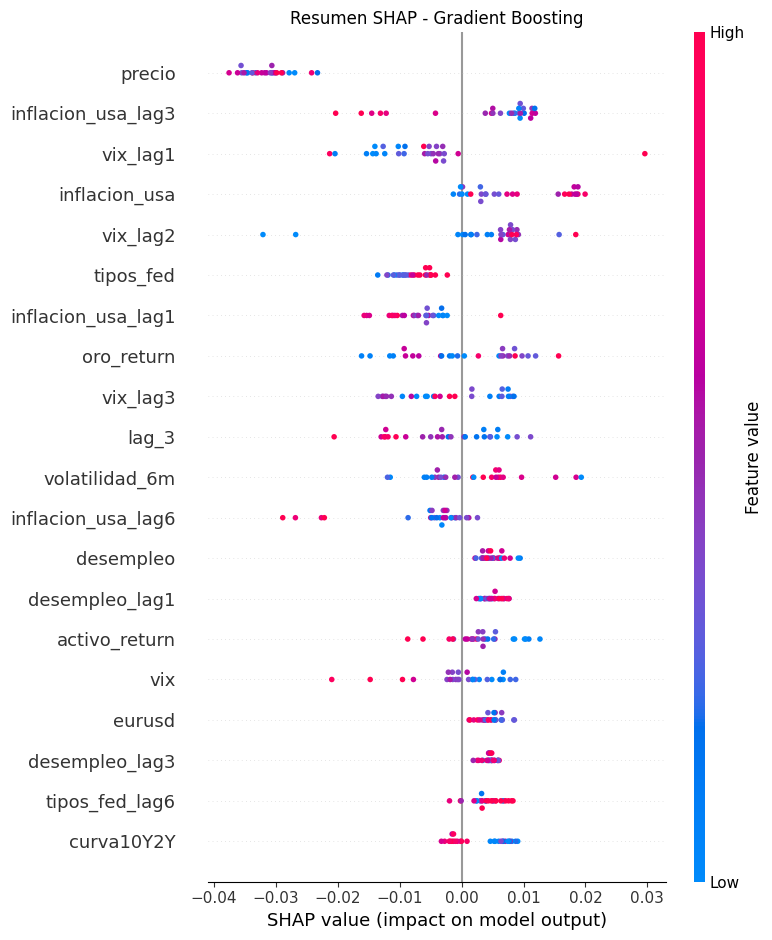

In [17]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_gb, X_test, show=False)
plt.title("Resumen SHAP - Gradient Boosting")
plt.tight_layout()
plt.show()

In [ ]:
mean_abs_shap_gb = np.abs(shap_values_gb).mean(axis=0)
feature_names = X_test.columns

importance_df_gb = pd.DataFrame({
    'Variable': feature_names,
    'Importancia_SHAP': mean_abs_shap_gb
}).sort_values('Importancia_SHAP', ascending=False)

print("\nTOP 10 VARIABLES MÁS IMPORTANTES (SHAP)")
print(importance_df_gb.head(10).to_string(index=False))



=== TOP 10 VARIABLES MÁS IMPORTANTES (SHAP) - GRADIENT BOOSTING ===
          Variable  Importancia_SHAP
            precio          0.031539
inflacion_usa_lag3          0.009742
          vix_lag1          0.009250
     inflacion_usa          0.008792
          vix_lag2          0.008356
         tipos_fed          0.008037
inflacion_usa_lag1          0.007711
        oro_return          0.007657
          vix_lag3          0.007149
             lag_3          0.006908


Variable más importante: precio


<Figure size 1000x600 with 0 Axes>

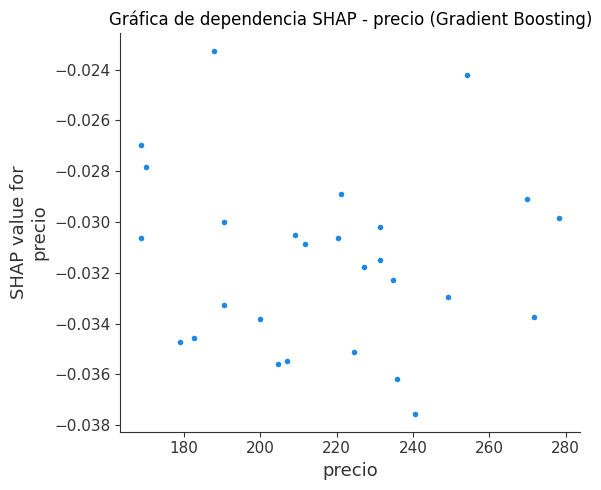

In [19]:
most_important_feature_gb = importance_df_gb.iloc[0]['Variable']
most_important_idx_gb = X_test.columns.get_loc(most_important_feature_gb)

print(f"Variable más importante: {most_important_feature_gb}")

plt.figure(figsize=(10, 6))
shap.dependence_plot(most_important_idx_gb, shap_values_gb, X_test, 
                     interaction_index=None, show=False)
plt.title(f"Gráfica de dependencia SHAP - {most_important_feature_gb} (Gradient Boosting)")
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

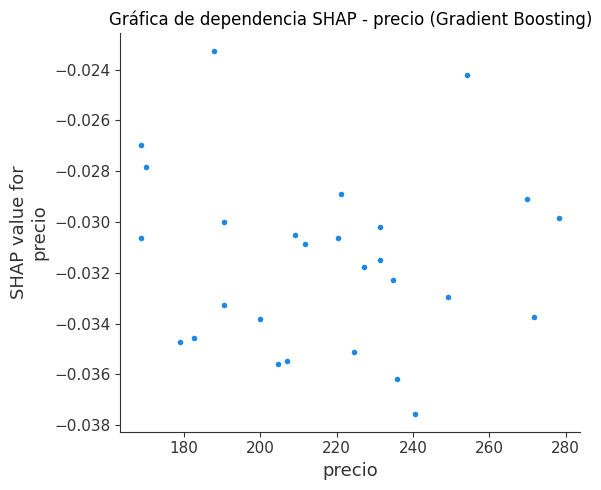

<Figure size 1000x600 with 0 Axes>

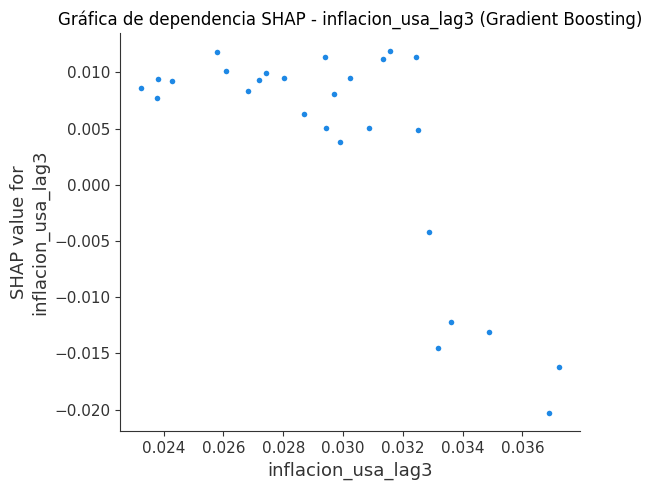

<Figure size 1000x600 with 0 Axes>

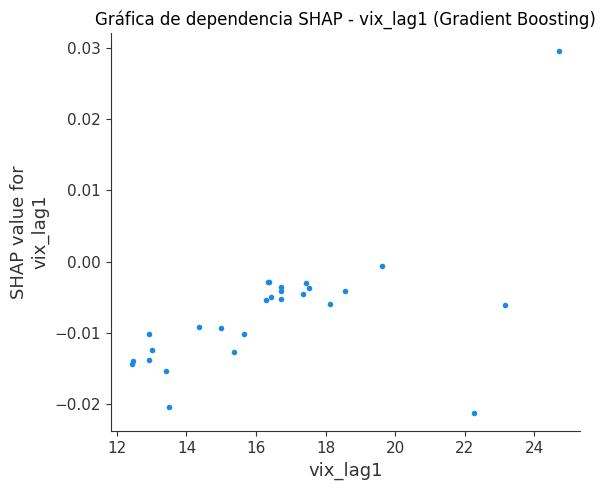

In [20]:
top_3_features_gb = importance_df_gb.head(3)['Variable'].values

for feature in top_3_features_gb:
    feature_idx = X_test.columns.get_loc(feature)
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(feature_idx, shap_values_gb, X_test, 
                         interaction_index=None, show=False)
    plt.title(f"Gráfica de dependencia SHAP - {feature} (Gradient Boosting)")
    plt.tight_layout()
    plt.show()

Forma de shap_values_for_plot: (26,)


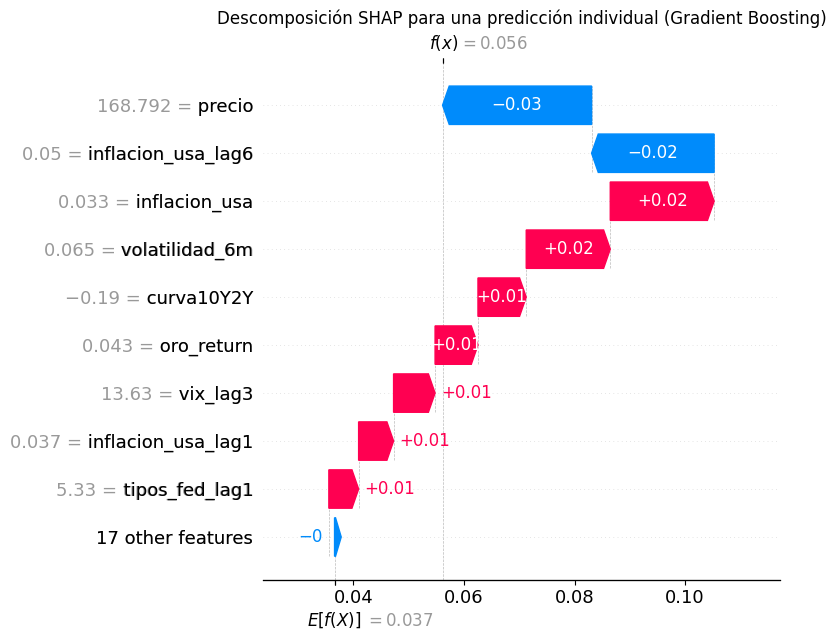

In [21]:
# Elegimos una muestra del conjunto de prueba (la primera)
sample_idx = 0
sample = X_test.iloc[sample_idx:sample_idx+1]

# Calcular valores SHAP para la muestra
shap_values_sample_gb = explainer_gb.shap_values(sample)

# Obtener el valor base como escalar
expected_value_gb = explainer_gb.expected_value
if isinstance(expected_value_gb, np.ndarray):
    expected_value_scalar_gb = expected_value_gb[0]
else:
    expected_value_scalar_gb = expected_value_gb

# Aplanar el array si es necesario
if len(shap_values_sample_gb.shape) > 1:
    shap_values_for_plot_gb = shap_values_sample_gb.flatten()
else:
    shap_values_for_plot_gb = shap_values_sample_gb

print(f"Forma de shap_values_for_plot: {shap_values_for_plot_gb.shape}")

# Crear el objeto Explanation
explanation_gb = shap.Explanation(
    values=shap_values_for_plot_gb,
    base_values=expected_value_scalar_gb,
    data=sample.iloc[0].values,
    feature_names=X_test.columns.tolist()
)

# Generar el waterfall plot
plt.figure(figsize=(12, 6))
shap.waterfall_plot(explanation_gb, show=False)
plt.title(f"Descomposición SHAP para una predicción individual (Gradient Boosting)")
plt.tight_layout()
plt.show()

<Figure size 1400x400 with 0 Axes>

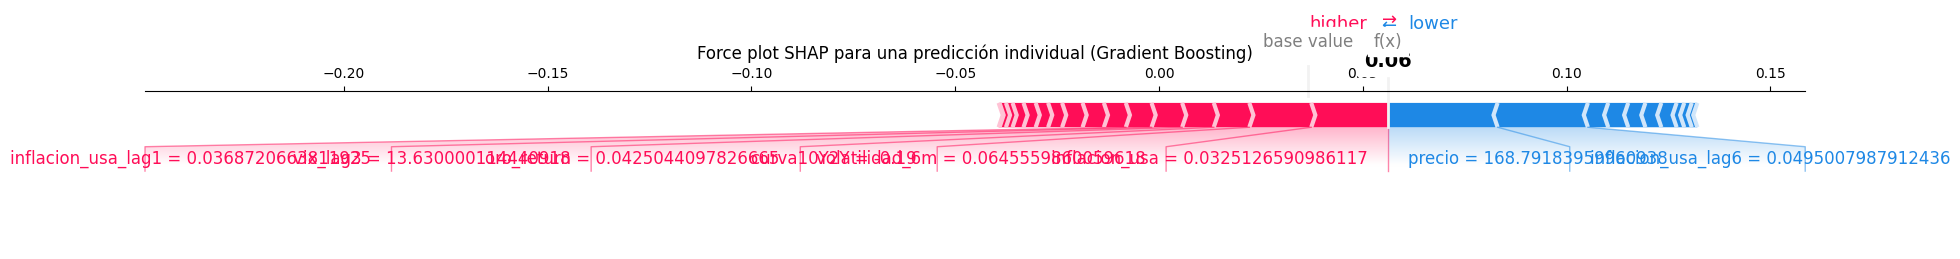

In [22]:
plt.figure(figsize=(14, 4))
# Para force plot necesitamos pasar los shap values en el formato correcto
shap.force_plot(expected_value_scalar_gb, shap_values_for_plot_gb, sample, 
                matplotlib=True, show=False)
plt.title(f"Force plot SHAP para una predicción individual (Gradient Boosting)")
plt.tight_layout()
plt.show()

In [23]:
feature_names = X_train.columns.tolist()

# Crear el explainer LIME (tabular)
explainer_lime_gb = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=feature_names,
    mode='regression',  # Es un problema de regresión
    random_state=42,
    verbose=False
)

In [24]:
sample_idx = 0
sample = X_test.iloc[sample_idx:sample_idx+1]

print(f"Muestra seleccionada (índice {sample_idx}):")
print(f"Valor real: {y_test.iloc[sample_idx]:.4f}")
print(f"Predicción del modelo: {best_gb.predict(sample)[0]:.4f}")

Muestra seleccionada (índice 0):
Valor real: 0.1123
Predicción del modelo: 0.0561


In [25]:
exp_lime_gb = explainer_lime_gb.explain_instance(
    data_row=sample.values[0],
    predict_fn=best_gb.predict,
    num_features=10,  # Mostrar las 10 variables más importantes
    num_samples=5000
)

c:\Users\34620\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


In [ ]:
print("\nEXPLICACIÓN LIME PARA RANDOM FOREST")
print(exp_lime_gb.as_list())



=== EXPLICACIÓN LIME PARA RANDOM FOREST ===
[('precio > 31.96', -0.026427239095675018), ('inflacion_usa_lag6 > 0.03', -0.015361467947295513), ('16.38 < vix_lag1 <= 22.16', -0.012932587917086824), ('inflacion_usa_lag3 > 0.03', -0.012664817219361123), ('desempleo <= 4.70', 0.007272988650480598), ('desempleo_lag3 <= 4.70', 0.007227943891700874), ('tipos_fed > 2.02', -0.0070088051721974454), ('0.06 < volatilidad_6m <= 0.08', 0.006970339320870577), ('13.42 < vix_lag3 <= 16.48', 0.006935352037834397), ('desempleo_lag1 <= 4.70', 0.0067731149035693125)]


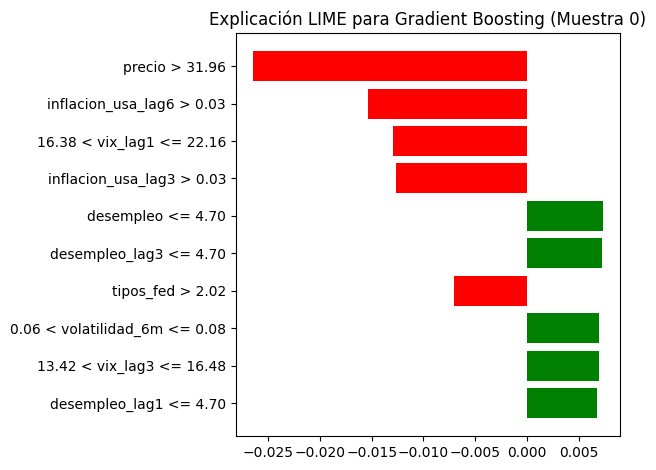

In [27]:
# La figura se guardará como 'lime_rf.png'
fig = exp_lime_gb.as_pyplot_figure()
plt.title(f"Explicación LIME para Gradient Boosting (Muestra {sample_idx})")
plt.tight_layout()
plt.savefig('lime_rf.png', dpi=150, bbox_inches='tight')
plt.show()
